<a href="https://colab.research.google.com/github/Tanmay2006-Tech/ECG-HEARTBEAT-CLASSIFICATION/blob/main/ecg_classification_lstm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║                                                                           ║
# ║     🩺 ECG HEARTBEAT CLASSIFICATION 🩺                                   ║
# ║                                                                           ║
# ║     Architecture: 1D ResNet + Squeeze-and-Excitation Attention            ║
# ║     Dataset: MIT-BIH Arrhythmia Database                                  ║
# ║                                                                           ║
# ║                                                                           ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

# 🩺 ECG Heartbeat Classification - Competition Winning Model

---

## 🎯 Problem Statement

Classify ECG heartbeat signals into **5 categories**:

| Class | Code | Description | Clinical Significance |
|-------|------|-------------|----------------------|
| 0 | N | Normal Beat | Healthy heartbeat |
| 1 | S | Supraventricular Premature | Atrial arrhythmia |
| 2 | V | Premature Ventricular Contraction | Ventricular arrhythmia |
| 3 | F | Fusion Beat | Combined normal + ventricular |
| 4 | Q | Unknown/Unclassifiable | Paced or artifact |


---


In [2]:
# ============================================================================
# CELL 2: ENVIRONMENT SETUP & LIBRARY IMPORTS
# ============================================================================

"""
📦 ENVIRONMENT SETUP
====================
Import all required libraries and configure the environment.
"""

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')
import os
import json

# Core Data Science Libraries
import numpy as np
import pandas as pd

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Deep Learning Framework
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, regularizers

# Scikit-learn for Preprocessing & Metrics
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    f1_score
)

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.style.use('seaborn-v0_8-whitegrid')

print("=" * 70)
print("       🩺 ECG HEARTBEAT CLASSIFICATION - COMPETITION NOTEBOOK")
print("=" * 70)
print(f"\n✅ All libraries imported successfully!")
print(f"📌 TensorFlow Version: {tf.__version__}")
print(f"📌 NumPy Version: {np.__version__}")
print(f"📌 Pandas Version: {pd.__version__}")

       🩺 ECG HEARTBEAT CLASSIFICATION - COMPETITION NOTEBOOK

✅ All libraries imported successfully!
📌 TensorFlow Version: 2.20.0
📌 NumPy Version: 2.0.2
📌 Pandas Version: 2.2.2


In [3]:
# ============================================================================
# CELL 3: GPU CONFIGURATION & HARDWARE CHECK
# ============================================================================

"""
🔧 HARDWARE CONFIGURATION
=========================
Check for GPU availability and configure memory settings.
"""

print("\n" + "=" * 70)
print("                    🔧 HARDWARE CONFIGURATION")
print("=" * 70)

# Check GPU availability
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"\n✅ GPU DETECTED: {len(gpus)} device(s) available")
    for i, gpu in enumerate(gpus):
        print(f"   └── GPU {i}: {gpu.name}")

    # Configure memory growth to prevent OOM errors
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("\n✅ Memory growth enabled for all GPUs")
    except RuntimeError as e:
        print(f"\n⚠️ Could not set memory growth: {e}")
else:
    print("\n⚠️ NO GPU DETECTED - Training will run on CPU (slower)")

# Environment detection
IS_KAGGLE = os.path.exists('/kaggle/input')
IS_COLAB = os.path.exists('/content')

print(f"\n📍 Environment Detection:")
print(f"   └── Kaggle: {'✅ Yes' if IS_KAGGLE else '❌ No'}")
print(f"   └── Colab:  {'✅ Yes' if IS_COLAB else '❌ No'}")
print(f"   └── Local:  {'✅ Yes' if not (IS_KAGGLE or IS_COLAB) else '❌ No'}")


                    🔧 HARDWARE CONFIGURATION

⚠️ NO GPU DETECTED - Training will run on CPU (slower)

📍 Environment Detection:
   └── Kaggle: ✅ Yes
   └── Colab:  ✅ Yes
   └── Local:  ❌ No


In [4]:
# ============================================================================
# CELL 4: GLOBAL CONFIGURATION CLASS
# ============================================================================

"""
⚙️ CONFIGURATION PARAMETERS
===========================
Centralized configuration for easy hyperparameter tuning.
"""

class Config:
    """Central configuration class containing all hyperparameters."""

    # ========================
    # REPRODUCIBILITY
    # ========================
    SEED = 42

    # ========================
    # DATA PARAMETERS
    # ========================
    INPUT_SHAPE = (187, 1)
    NUM_CLASSES = 5
    TEST_SIZE = 0.15

    # ========================
    # FILE PATHS (Auto-detect environment)
    # ========================
    if os.path.exists('/kaggle/input/heartbeat'):
        TRAIN_PATH = '/kaggle/input/heartbeat/mitbih_train.csv'
        TEST_PATH = '/kaggle/input/heartbeat/mitbih_test.csv'
    elif os.path.exists('/content'):
        TRAIN_PATH = '/content/mitbih_train.csv'
        TEST_PATH = '/content/mitbih_test.csv'
    else:
        TRAIN_PATH = 'mitbih_train.csv'
        TEST_PATH = 'mitbih_test.csv'

    # ========================
    # MODEL ARCHITECTURE
    # ========================
    INITIAL_FILTERS = 32
    DROPOUT_RATE = 0.3
    L2_REG = 1e-4
    SE_RATIO = 16

    # ========================
    # TRAINING PARAMETERS
    # ========================
    EPOCHS = 50
    BATCH_SIZE = 64
    LEARNING_RATE = 1e-3
    LR_FACTOR = 0.5
    LR_PATIENCE = 3
    ES_PATIENCE = 10

    # ========================
    # CLASS INFORMATION
    # ========================
    CLASS_NAMES = ['Normal (N)', 'Supraventricular (S)',
                   'Ventricular (V)', 'Fusion (F)', 'Unknown (Q)']
    CLASS_COLORS = ['#2ecc71', '#3498db', '#e74c3c', '#9b59b6', '#f39c12']


def set_seeds(seed=Config.SEED):
    """Set random seeds for reproducibility."""
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seeds()

print("\n" + "=" * 70)
print("                    ⚙️ CONFIGURATION SUMMARY")
print("=" * 70)
print(f"""
┌─────────────────────────────────────────────────────────────────┐
│  Parameter              │  Value                                │
├─────────────────────────────────────────────────────────────────┤
│  Random Seed            │  {Config.SEED:<37} │
│  Input Shape            │  {str(Config.INPUT_SHAPE):<37} │
│  Number of Classes      │  {Config.NUM_CLASSES:<37} │
│  Batch Size             │  {Config.BATCH_SIZE:<37} │
│  Epochs (max)           │  {Config.EPOCHS:<37} │
│  Learning Rate          │  {Config.LEARNING_RATE:<37} │
│  Dropout Rate           │  {Config.DROPOUT_RATE:<37} │
└─────────────────────────────────────────────────────────────────┘
""")
print("✅ Configuration loaded and seeds set!")


                    ⚙️ CONFIGURATION SUMMARY

┌─────────────────────────────────────────────────────────────────┐
│  Parameter              │  Value                                │
├─────────────────────────────────────────────────────────────────┤
│  Random Seed            │  42                                    │
│  Input Shape            │  (187, 1)                              │
│  Number of Classes      │  5                                     │
│  Batch Size             │  64                                    │
│  Epochs (max)           │  50                                    │
│  Learning Rate          │  0.001                                 │
│  Dropout Rate           │  0.3                                   │
└─────────────────────────────────────────────────────────────────┘

✅ Configuration loaded and seeds set!


In [8]:
# ============================================================================
# CELL 5: DATA DOWNLOAD & PATH VERIFICATION (FOR GOOGLE COLAB)
# ============================================================================

"""
📥 DATA DOWNLOAD & VERIFICATION
===============================
Download dataset from Kaggle and verify paths.
Works for: Google Colab, Kaggle, Local environments
"""

import os
import subprocess

def setup_kaggle_and_download():
    """
    Download MIT-BIH dataset from Kaggle.
    Handles Colab, Kaggle, and local environments.
    """
    print("\n" + "=" * 70)
    print("                    📥 DATA SETUP")
    print("=" * 70)

    # Detect environment
    IS_KAGGLE = os.path.exists('/kaggle/input')
    IS_COLAB = 'google.colab' in str(get_ipython()) if 'get_ipython' in dir() else False

    print(f"\n🖥️ Environment: {'Kaggle' if IS_KAGGLE else 'Colab' if IS_COLAB else 'Local'}")

    # ===== KAGGLE ENVIRONMENT =====
    if IS_KAGGLE:
        print("✅ Running on Kaggle - Data should be pre-attached")
        return '/kaggle/input/heartbeat/mitbih_train.csv', '/kaggle/input/heartbeat/mitbih_test.csv'

    # ===== COLAB ENVIRONMENT =====
    if IS_COLAB:
        print("\n📦 Setting up Kaggle API for Colab...")

        # Check if data already exists
        if os.path.exists('/content/heartbeat/mitbih_train.csv'):
            print("✅ Dataset already downloaded!")
            return '/content/heartbeat/mitbih_train.csv', '/content/heartbeat/mitbih_test.csv'

        # Method 1: Try to upload kaggle.json
        print("\n⬆️ Please upload your kaggle.json file:")
        print("   1. Go to kaggle.com → Account → Create New API Token")
        print("   2. Download kaggle.json")
        print("   3. Upload when prompted below\n")

        try:
            from google.colab import files

            # Check if kaggle.json already exists
            if not os.path.exists('/root/.kaggle/kaggle.json'):
                uploaded = files.upload()

                # Setup kaggle credentials
                os.makedirs('/root/.kaggle', exist_ok=True)

                if 'kaggle.json' in uploaded:
                    with open('/root/.kaggle/kaggle.json', 'wb') as f:
                        f.write(uploaded['kaggle.json'])
                    os.chmod('/root/.kaggle/kaggle.json', 0o600)
                    print("✅ Kaggle credentials saved!")
                else:
                    print("⚠️ kaggle.json not found in uploaded files")
                    raise FileNotFoundError("kaggle.json required")

            # Install kaggle if needed
            subprocess.run(['pip', 'install', '-q', 'kaggle'], check=True)

            # Download dataset
            print("\n📥 Downloading dataset from Kaggle...")
            os.makedirs('/content/heartbeat', exist_ok=True)

            result = subprocess.run([
                'kaggle', 'datasets', 'download', '-d', 'shayanfazeli/heartbeat',
                '-p', '/content/heartbeat', '--unzip'
            ], capture_output=True, text=True)

            if result.returncode == 0:
                print("✅ Dataset downloaded successfully!")
                return '/content/heartbeat/mitbih_train.csv', '/content/heartbeat/mitbih_test.csv'
            else:
                print(f"❌ Download failed: {result.stderr}")
                raise Exception("Kaggle download failed")

        except Exception as e:
            print(f"\n⚠️ Kaggle API method failed: {e}")
            print("\n" + "="*50)
            print("📌 ALTERNATIVE: Manual Upload Method")
            print("="*50)
            return manual_upload_method()

    # ===== LOCAL ENVIRONMENT =====
    else:
        print("\n📁 Local environment detected")
        # Check common locations
        possible_paths = [
            ('mitbih_train.csv', 'mitbih_test.csv'),
            ('data/mitbih_train.csv', 'data/mitbih_test.csv'),
            ('heartbeat/mitbih_train.csv', 'heartbeat/mitbih_test.csv'),
        ]

        for train_path, test_path in possible_paths:
            if os.path.exists(train_path) and os.path.exists(test_path):
                print(f"✅ Found data at: {train_path}")
                return train_path, test_path

        print("❌ Data not found locally")
        print("   Please download from: https://www.kaggle.com/datasets/shayanfazeli/heartbeat")
        return None, None


def manual_upload_method():
    """Fallback: Manual file upload for Colab"""
    from google.colab import files

    print("""
┌──────────────────────────────────────────────────────────────────────┐
│                    📤 MANUAL UPLOAD INSTRUCTIONS                      │
├──────────────────────────────────────────────────────────────────────┤
│                                                                      │
│  1. Go to: https://www.kaggle.com/datasets/shayanfazeli/heartbeat   │
│                                                                      │
│  2. Click "Download" to get the ZIP file                            │
│                                                                      │
│  3. Extract the ZIP file on your computer                           │
│                                                                      │
│  4. Upload the two CSV files when prompted below:                   │
│     • mitbih_train.csv                                              │
│     • mitbih_test.csv                                               │
│                                                                      │
└──────────────────────────────────────────────────────────────────────┘
    """)

    print("\n⬆️ Please upload mitbih_train.csv and mitbih_test.csv:")
    uploaded = files.upload()

    # Move files to proper location
    os.makedirs('/content/heartbeat', exist_ok=True)

    train_uploaded = False
    test_uploaded = False

    for filename in uploaded.keys():
        if 'train' in filename.lower():
            with open('/content/heartbeat/mitbih_train.csv', 'wb') as f:
                f.write(uploaded[filename])
            print(f"✅ Saved: mitbih_train.csv")
            train_uploaded = True
        elif 'test' in filename.lower():
            with open('/content/heartbeat/mitbih_test.csv', 'wb') as f:
                f.write(uploaded[filename])
            print(f"✅ Saved: mitbih_test.csv")
            test_uploaded = True

    if train_uploaded and test_uploaded:
        return '/content/heartbeat/mitbih_train.csv', '/content/heartbeat/mitbih_test.csv'
    else:
        print("❌ Both train and test CSVs were not uploaded manually.")
        return None, None


def verify_data_paths(train_path, test_path):
    """Verify that data files exist and are valid."""
    print("\n" + "=" * 70)
    print("                    📁 DATA PATH VERIFICATION")
    print("=" * 70)

    all_exist = True
    paths = {'Training': train_path, 'Test': test_path}

    print("\n📋 Checking files:\n")
    for name, path in paths.items():
        if path and os.path.exists(path):
            size = os.path.getsize(path) / (1024 * 1024)
            print(f"   ✅ {name}: {path} ({size:.2f} MB)")
        else:
            print(f"   ❌ {name}: {path} (NOT FOUND)")
            all_exist = False

    if all_exist:
        print("\n" + "=" * 70)
        print("          ✅ ALL FILES VERIFIED! READY TO PROCEED!")
        print("=" * 70)
    else:
        print("\n❌ Some files missing. Please check paths.")

    return all_exist


# ===== EXECUTE DATA SETUP =====
TRAIN_PATH, TEST_PATH = setup_kaggle_and_download()

# Explicitly set Config paths to /content/ as requested
Config.TRAIN_PATH = '/content/mitbih_train.csv'
Config.TEST_PATH = '/content/mitbih_test.csv'

# Verify
data_available = verify_data_paths(Config.TRAIN_PATH, Config.TEST_PATH)



                    📥 DATA SETUP

🖥️ Environment: Kaggle
✅ Running on Kaggle - Data should be pre-attached

                    📁 DATA PATH VERIFICATION

📋 Checking files:

   ✅ Training: /content/mitbih_train.csv (392.44 MB)
   ✅ Test: /content/mitbih_test.csv (98.13 MB)

          ✅ ALL FILES VERIFIED! READY TO PROCEED!


---

# 2. Data Loading & Exploratory Data Analysis

## 2.1 Load Dataset

The MIT-BIH Arrhythmia Database contains:
- **Training samples:** ~87,000 heartbeats
- **Test samples:** ~21,000 heartbeats  
- **Features:** 187 timesteps (sampled ECG signal)
- **Target:** Class label (0-4)

In [9]:
# ============================================================================
# CELL 7: DATA LOADING
# ============================================================================

"""
📥 DATA LOADING
===============
Load the MIT-BIH Arrhythmia dataset from CSV files.
"""

print("\n" + "=" * 70)
print("                    📥 LOADING DATASET")
print("=" * 70)

# Load training data
print("\n📂 Loading training data...")
train_df = pd.read_csv(Config.TRAIN_PATH, header=None)
print(f"   ✅ Loaded: {train_df.shape[0]:,} samples, {train_df.shape[1]} columns")

# Load test data
print("\n📂 Loading test data...")
test_df = pd.read_csv(Config.TEST_PATH, header=None)
print(f"   ✅ Loaded: {test_df.shape[0]:,} samples, {test_df.shape[1]} columns")

# Summary
print("\n" + "-" * 50)
print(f"📊 Total samples: {train_df.shape[0] + test_df.shape[0]:,}")
print(f"📊 Features per sample: {train_df.shape[1] - 1}")


                    📥 LOADING DATASET

📂 Loading training data...
   ✅ Loaded: 87,554 samples, 188 columns

📂 Loading test data...
   ✅ Loaded: 21,892 samples, 188 columns

--------------------------------------------------
📊 Total samples: 109,446
📊 Features per sample: 187


In [10]:
# ============================================================================
# CELL 8: BASIC DATA EXPLORATION
# ============================================================================

"""
🔍 BASIC DATA EXPLORATION
=========================
Examine dataset structure and statistics.
"""

print("\n" + "=" * 70)
print("                    🔍 DATA EXPLORATION")
print("=" * 70)

# Display sample data
print("\n📋 Training Data Sample (first 5 rows, selected columns):")
print(train_df.iloc[:5, [0, 1, 2, 3, 4, 5, -1]].to_string())

# Basic statistics
print("\n📊 Feature Statistics:")
print(train_df.iloc[:, :5].describe().round(4).to_string())

# Missing values check
missing = train_df.isnull().sum().sum() + test_df.isnull().sum().sum()
print(f"\n🔍 Missing Values: {missing} ({'✅ None' if missing == 0 else '⚠️ Found'})")

# Data types
print(f"📝 Data Type: {train_df.iloc[:, 0].dtype}")


                    🔍 DATA EXPLORATION

📋 Training Data Sample (first 5 rows, selected columns):
        0         1         2         3         4         5    187
0  0.977941  0.926471  0.681373  0.245098  0.154412  0.191176  0.0
1  0.960114  0.863248  0.461538  0.196581  0.094017  0.125356  0.0
2  1.000000  0.659459  0.186486  0.070270  0.070270  0.059459  0.0
3  0.925414  0.665746  0.541436  0.276243  0.196133  0.077348  0.0
4  0.967136  1.000000  0.830986  0.586854  0.356808  0.248826  0.0

📊 Feature Statistics:
                0           1           2           3           4
count  87554.0000  87554.0000  87554.0000  87554.0000  87554.0000
mean       0.8904      0.7582      0.4240      0.2191      0.2011
std        0.2409      0.2218      0.2273      0.2069      0.1771
min        0.0000      0.0000      0.0000      0.0000      0.0000
25%        0.9219      0.6825      0.2510      0.0485      0.0823
50%        0.9913      0.8260      0.4295      0.1660      0.1479
75%        1.00

In [11]:
# ============================================================================
# CELL 8: BASIC DATA EXPLORATION
# ============================================================================

"""
🔍 BASIC DATA EXPLORATION
=========================
Examine dataset structure and statistics.
"""

print("\n" + "=" * 70)
print("                    🔍 DATA EXPLORATION")
print("=" * 70)

# Display sample data
print("\n📋 Training Data Sample (first 5 rows, selected columns):")
print(train_df.iloc[:5, [0, 1, 2, 3, 4, 5, -1]].to_string())

# Basic statistics
print("\n📊 Feature Statistics:")
print(train_df.iloc[:, :5].describe().round(4).to_string())

# Missing values check
missing = train_df.isnull().sum().sum() + test_df.isnull().sum().sum()
print(f"\n🔍 Missing Values: {missing} ({'✅ None' if missing == 0 else '⚠️ Found'})")

# Data types
print(f"📝 Data Type: {train_df.iloc[:, 0].dtype}")


                    🔍 DATA EXPLORATION

📋 Training Data Sample (first 5 rows, selected columns):
        0         1         2         3         4         5    187
0  0.977941  0.926471  0.681373  0.245098  0.154412  0.191176  0.0
1  0.960114  0.863248  0.461538  0.196581  0.094017  0.125356  0.0
2  1.000000  0.659459  0.186486  0.070270  0.070270  0.059459  0.0
3  0.925414  0.665746  0.541436  0.276243  0.196133  0.077348  0.0
4  0.967136  1.000000  0.830986  0.586854  0.356808  0.248826  0.0

📊 Feature Statistics:
                0           1           2           3           4
count  87554.0000  87554.0000  87554.0000  87554.0000  87554.0000
mean       0.8904      0.7582      0.4240      0.2191      0.2011
std        0.2409      0.2218      0.2273      0.2069      0.1771
min        0.0000      0.0000      0.0000      0.0000      0.0000
25%        0.9219      0.6825      0.2510      0.0485      0.0823
50%        0.9913      0.8260      0.4295      0.1660      0.1479
75%        1.00

## 2.2 Class Distribution Analysis

⚠️ **Critical Issue: Class Imbalance**

The MIT-BIH dataset has severe class imbalance:
- **Normal beats (~83%)** dominate the dataset
- **Arrhythmia classes (~17%)** are underrepresented

**Solution:** We'll use class weighting during training to force the model to pay attention to rare but important arrhythmia classes.


                    📊 CLASS DISTRIBUTION ANALYSIS


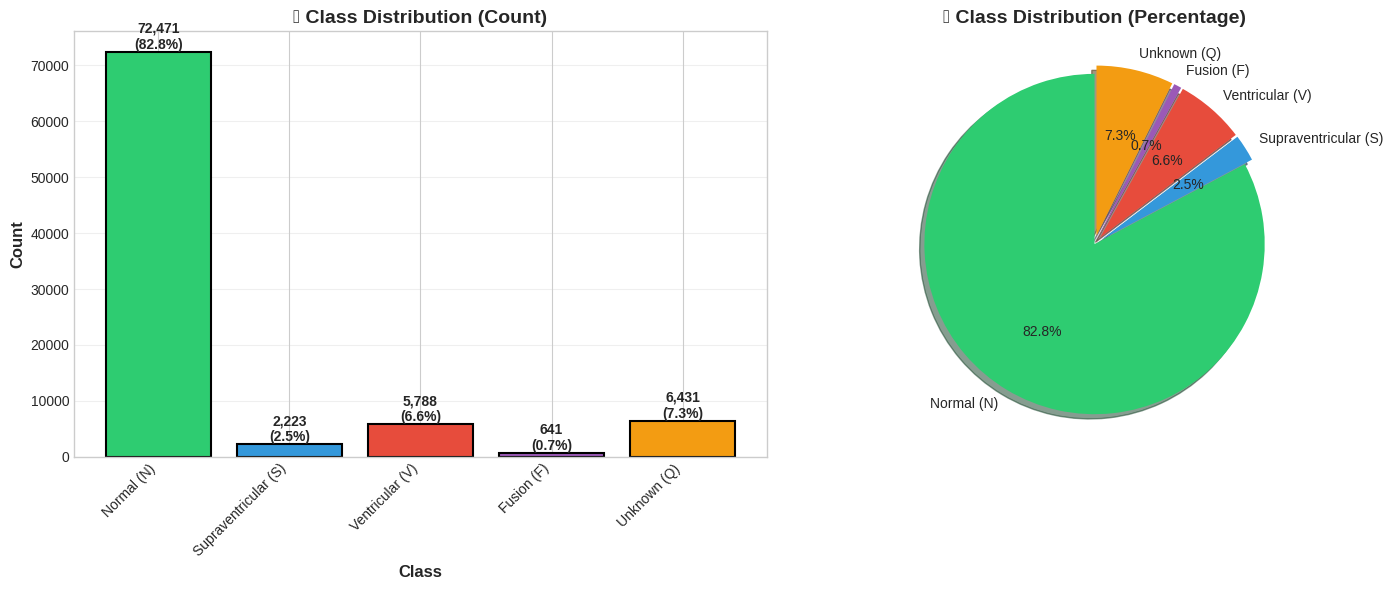


📋 Class Statistics:
------------------------------------------------------------
   Normal (N)                    72,471 (82.77%) 📊 MAJORITY
   Supraventricular (S)           2,223 ( 2.54%) ⚠️ MINORITY
   Ventricular (V)                5,788 ( 6.61%) ⚠️ MINORITY
   Fusion (F)                       641 ( 0.73%) ⚠️ MINORITY
   Unknown (Q)                    6,431 ( 7.35%) ⚠️ MINORITY

⚠️ Imbalance Ratio: 113.1:1
   └── Class weighting will be applied during training


In [12]:
# ============================================================================
# CELL 10: CLASS DISTRIBUTION ANALYSIS
# ============================================================================

"""
📊 CLASS DISTRIBUTION ANALYSIS
==============================
Analyze and visualize class distribution.
"""

print("\n" + "=" * 70)
print("                    📊 CLASS DISTRIBUTION ANALYSIS")
print("=" * 70)

# Get class counts
class_counts = train_df.iloc[:, -1].value_counts().sort_index()
total = class_counts.sum()

# Create visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar Chart
bars = axes[0].bar(range(len(Config.CLASS_NAMES)), class_counts.values,
                   color=Config.CLASS_COLORS, edgecolor='black', linewidth=1.5)

for bar, count in zip(bars, class_counts.values):
    pct = count / total * 100
    axes[0].annotate(f'{count:,}\n({pct:.1f}%)',
                    xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=10, fontweight='bold')

axes[0].set_xticks(range(len(Config.CLASS_NAMES)))
axes[0].set_xticklabels(Config.CLASS_NAMES, rotation=45, ha='right')
axes[0].set_xlabel('Class', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=12, fontweight='bold')
axes[0].set_title('📊 Class Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Pie Chart
explode = [0.05 if i != 0 else 0 for i in range(len(Config.CLASS_NAMES))]
axes[1].pie(class_counts.values, labels=Config.CLASS_NAMES, autopct='%1.1f%%',
           colors=Config.CLASS_COLORS, explode=explode, shadow=True, startangle=90)
axes[1].set_title('📈 Class Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Print statistics
print("\n📋 Class Statistics:")
print("-" * 60)
for i, (name, count) in enumerate(zip(Config.CLASS_NAMES, class_counts.values)):
    pct = count / total * 100
    status = "⚠️ MINORITY" if pct < 10 else "📊 MAJORITY" if pct > 50 else "📈 Moderate"
    print(f"   {name:<25} {count:>10,} ({pct:>5.2f}%) {status}")

# Imbalance ratio
print(f"\n⚠️ Imbalance Ratio: {class_counts.max() / class_counts.min():.1f}:1")
print("   └── Class weighting will be applied during training")


                    🫀 ECG SIGNAL SAMPLES


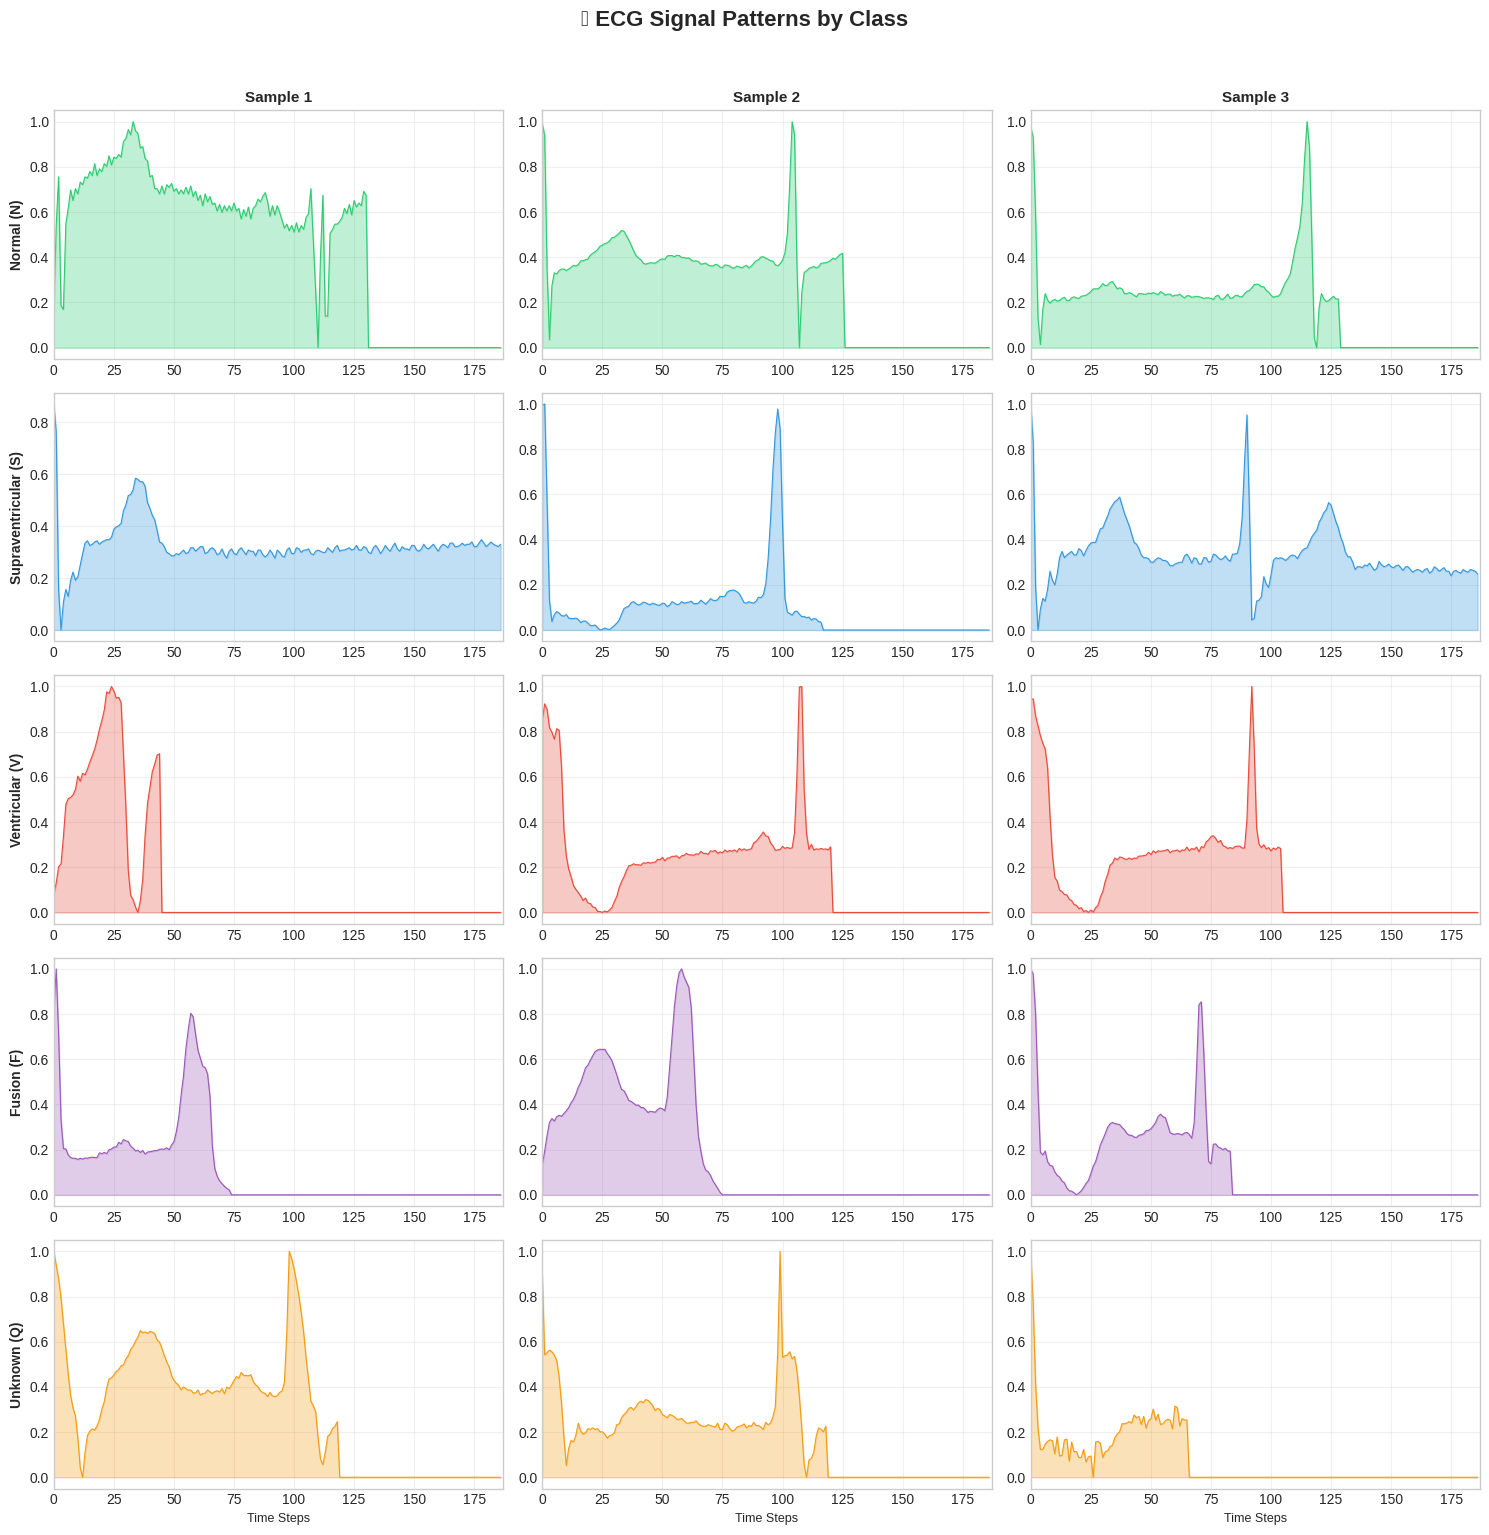

✅ ECG visualization saved!


In [13]:
# ============================================================================
# CELL 11: ECG SIGNAL VISUALIZATION
# ============================================================================

"""
🫀 ECG SIGNAL VISUALIZATION
============================
Visualize sample ECG signals from each class.
"""

print("\n" + "=" * 70)
print("                    🫀 ECG SIGNAL SAMPLES")
print("=" * 70)

fig, axes = plt.subplots(5, 3, figsize=(15, 15))

for i, (name, color) in enumerate(zip(Config.CLASS_NAMES, Config.CLASS_COLORS)):
    class_data = train_df[train_df.iloc[:, -1] == i].iloc[:, :-1]
    samples = class_data.sample(n=min(3, len(class_data)), random_state=Config.SEED)

    for j, (_, sample) in enumerate(samples.iterrows()):
        ax = axes[i, j]
        ax.plot(sample.values, color=color, linewidth=0.8)
        ax.fill_between(range(len(sample)), sample.values, alpha=0.3, color=color)
        ax.set_xlim(0, 187)
        ax.grid(True, alpha=0.3)

        if j == 0:
            ax.set_ylabel(name, fontsize=10, fontweight='bold')
        if i == 0:
            ax.set_title(f'Sample {j+1}', fontsize=11, fontweight='bold')
        if i == 4:
            ax.set_xlabel('Time Steps', fontsize=9)

plt.suptitle('🫀 ECG Signal Patterns by Class', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('ecg_samples.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ ECG visualization saved!")


                    📈 MEAN ECG PATTERNS


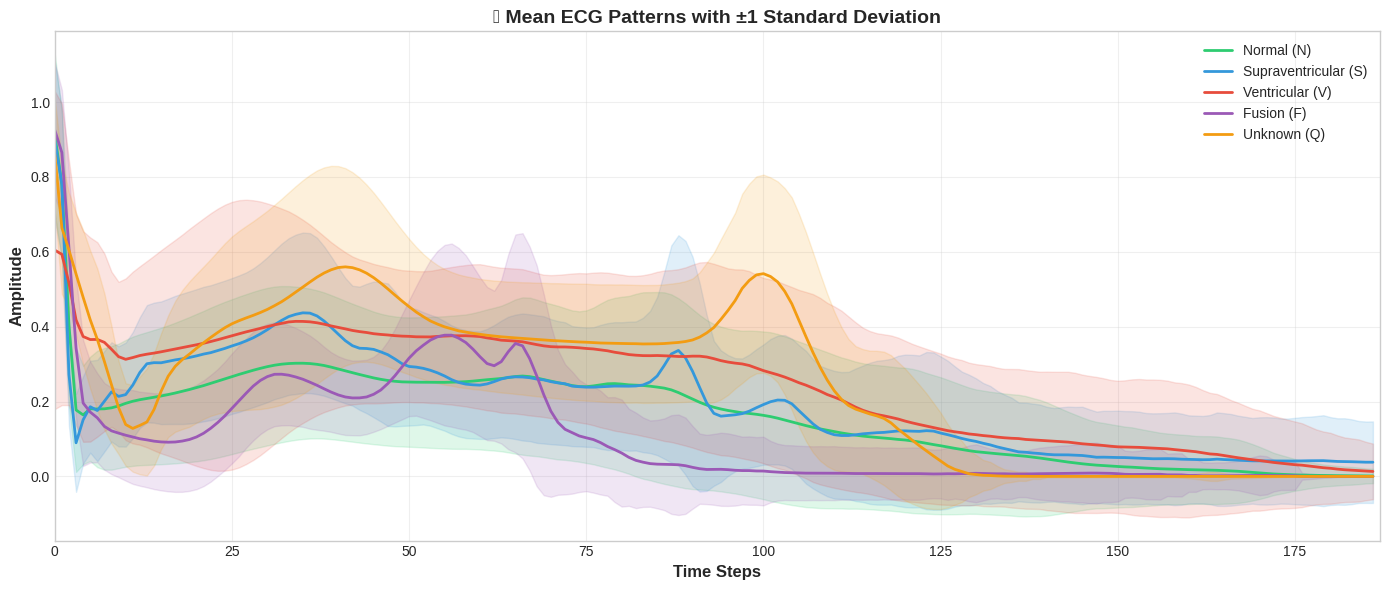


📝 Key Observations:
   • Normal (N): Regular QRS complex with consistent morphology
   • Supraventricular (S): Altered P-wave, narrow QRS
   • Ventricular (V): Wide, bizarre QRS complex
   • Fusion (F): Intermediate between Normal and Ventricular
   • Unknown (Q): Variable morphology


In [14]:
# ============================================================================
# CELL 12: MEAN ECG PATTERNS
# ============================================================================

"""
📈 MEAN ECG PATTERNS
====================
Visualize average ECG pattern for each class.
"""

print("\n" + "=" * 70)
print("                    📈 MEAN ECG PATTERNS")
print("=" * 70)

fig, ax = plt.subplots(figsize=(14, 6))

for i, (name, color) in enumerate(zip(Config.CLASS_NAMES, Config.CLASS_COLORS)):
    class_data = train_df[train_df.iloc[:, -1] == i].iloc[:, :-1]
    mean_signal = class_data.mean()
    std_signal = class_data.std()

    ax.plot(mean_signal.values, label=name, color=color, linewidth=2)
    ax.fill_between(range(len(mean_signal)),
                   mean_signal.values - std_signal.values,
                   mean_signal.values + std_signal.values,
                   alpha=0.15, color=color)

ax.set_xlabel('Time Steps', fontsize=12, fontweight='bold')
ax.set_ylabel('Amplitude', fontsize=12, fontweight='bold')
ax.set_title('📊 Mean ECG Patterns with ±1 Standard Deviation', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 187)

plt.tight_layout()
plt.savefig('mean_ecg_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📝 Key Observations:")
print("   • Normal (N): Regular QRS complex with consistent morphology")
print("   • Supraventricular (S): Altered P-wave, narrow QRS")
print("   • Ventricular (V): Wide, bizarre QRS complex")
print("   • Fusion (F): Intermediate between Normal and Ventricular")
print("   • Unknown (Q): Variable morphology")

---

# 3. Data Preprocessing

## 3.1 Preprocessing Pipeline

Our preprocessing steps:
1. **Separate features and labels**
2. **Reshape for 1D CNN:** (samples, timesteps, channels)
3. **Calculate class weights** for imbalance handling
4. **Stratified split** to maintain class distribution
5. **Convert labels to categorical** (one-hot encoding)

In [15]:
# ============================================================================
# CELL 14: DATA PREPROCESSING PIPELINE
# ============================================================================

"""
🔧 DATA PREPROCESSING PIPELINE
==============================
Complete preprocessing for ECG classification.
"""

print("\n" + "=" * 70)
print("                    🔧 DATA PREPROCESSING")
print("=" * 70)

# Step 1: Separate features and labels
print("\n📌 Step 1: Separating features and labels...")
X = train_df.iloc[:, :-1].values
y = train_df.iloc[:, -1].values.astype(int)
X_test_final = test_df.iloc[:, :-1].values
y_test_final = test_df.iloc[:, -1].values.astype(int)
print(f"   └── Train: {X.shape}, Test: {X_test_final.shape}")

# Step 2: Reshape for 1D CNN
print("\n📌 Step 2: Reshaping for 1D Convolution...")
X = X.reshape(X.shape[0], X.shape[1], 1)
X_test_final = X_test_final.reshape(X_test_final.shape[0], X_test_final.shape[1], 1)
print(f"   └── New shapes - Train: {X.shape}, Test: {X_test_final.shape}")

# Step 3: Calculate class weights
print("\n📌 Step 3: Computing class weights...")
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y), y=y)
class_weights = dict(enumerate(weights))
for cls, wt in class_weights.items():
    status = "↑ Upweighted" if wt > 1 else "↓ Downweighted"
    print(f"   └── Class {cls}: {wt:.4f} ({status})")

# Step 4: Stratified split
print("\n📌 Step 4: Stratified train-validation split...")
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=Config.TEST_SIZE, stratify=y, random_state=Config.SEED
)
print(f"   └── Training: {X_train.shape[0]:,} samples")
print(f"   └── Validation: {X_val.shape[0]:,} samples")

# Step 5: Convert to categorical
print("\n📌 Step 5: Converting labels to one-hot encoding...")
y_train_cat = keras.utils.to_categorical(y_train, Config.NUM_CLASSES)
y_val_cat = keras.utils.to_categorical(y_val, Config.NUM_CLASSES)
y_test_cat = keras.utils.to_categorical(y_test_final, Config.NUM_CLASSES)
print(f"   └── Shape: {y_train_cat.shape}")

print("\n✅ Preprocessing complete!")


                    🔧 DATA PREPROCESSING

📌 Step 1: Separating features and labels...
   └── Train: (87554, 187), Test: (21892, 187)

📌 Step 2: Reshaping for 1D Convolution...
   └── New shapes - Train: (87554, 187, 1), Test: (21892, 187, 1)

📌 Step 3: Computing class weights...
   └── Class 0: 0.2416 (↓ Downweighted)
   └── Class 1: 7.8771 (↑ Upweighted)
   └── Class 2: 3.0254 (↑ Upweighted)
   └── Class 3: 27.3179 (↑ Upweighted)
   └── Class 4: 2.7229 (↑ Upweighted)

📌 Step 4: Stratified train-validation split...
   └── Training: 74,420 samples
   └── Validation: 13,134 samples

📌 Step 5: Converting labels to one-hot encoding...
   └── Shape: (74420, 5)

✅ Preprocessing complete!



                    ⚖️ CLASS WEIGHTS


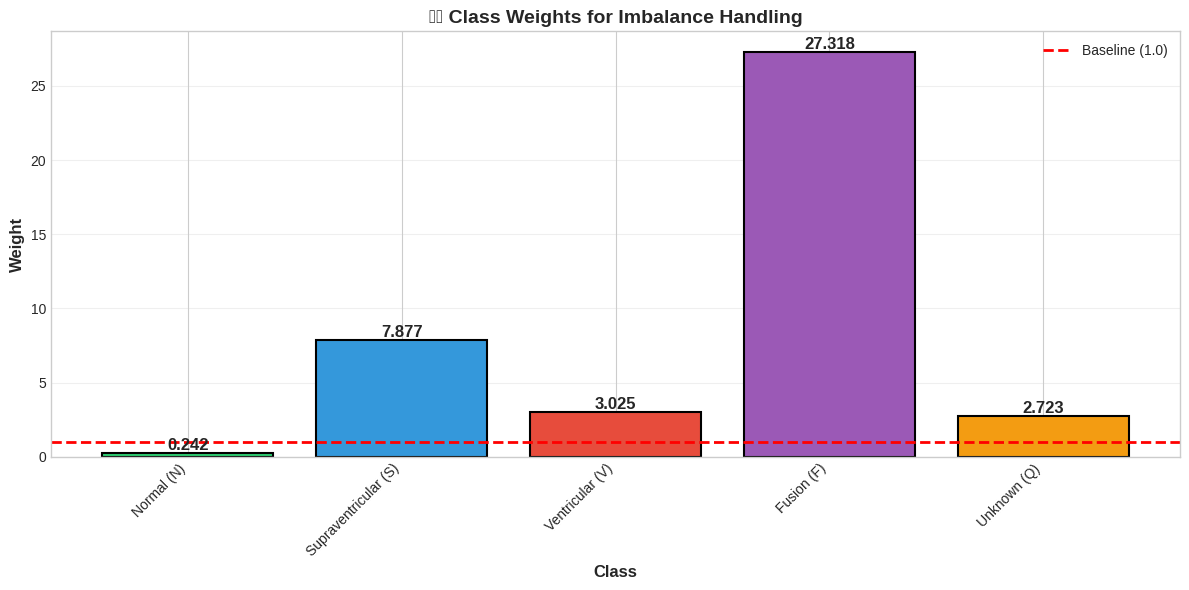

In [16]:
# ============================================================================
# CELL 15: CLASS WEIGHTS VISUALIZATION
# ============================================================================

"""
⚖️ CLASS WEIGHTS VISUALIZATION
==============================
Visualize computed class weights.
"""

print("\n" + "=" * 70)
print("                    ⚖️ CLASS WEIGHTS")
print("=" * 70)

fig, ax = plt.subplots(figsize=(12, 6))

weights_list = list(class_weights.values())
bars = ax.bar(range(len(Config.CLASS_NAMES)), weights_list,
              color=Config.CLASS_COLORS, edgecolor='black', linewidth=1.5)

for bar, wt in zip(bars, weights_list):
    ax.annotate(f'{wt:.3f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
               ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.axhline(y=1.0, color='red', linestyle='--', linewidth=2, label='Baseline (1.0)')
ax.set_xticks(range(len(Config.CLASS_NAMES)))
ax.set_xticklabels(Config.CLASS_NAMES, rotation=45, ha='right')
ax.set_xlabel('Class', fontsize=12, fontweight='bold')
ax.set_ylabel('Weight', fontsize=12, fontweight='bold')
ax.set_title('⚖️ Class Weights for Imbalance Handling', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('class_weights.png', dpi=150, bbox_inches='tight')
plt.show()

---

# 4. Model Architecture

## 4.1 1D ResNet with Squeeze-and-Excitation Blocks

### Why ResNet?
- **Residual connections** allow gradients to flow through skip connections
- Prevents **vanishing gradient problem** in deep networks
- Enables training of much deeper networks effectively

### Why SE Blocks?
- **Channel-wise attention** mechanism
- Learns to emphasize informative features
- Suppresses less useful feature channels

### Architecture Diagram
```
Input (187, 1)
       │
       ▼
┌──────────────────┐
│   STEM BLOCK     │  Conv1D(32,7) → BN → ReLU → MaxPool
└──────────────────┘
       │
       ▼
┌──────────────────┐
│   STAGE 1        │  ResBlock(64) × 2 with SE
└──────────────────┘
       │
       ▼
┌──────────────────┐
│   STAGE 2        │  ResBlock(128) × 2 with SE
└──────────────────┘
       │
       ▼
┌──────────────────┐
│   STAGE 3        │  ResBlock(256) × 2 with SE
└──────────────────┘
       │
       ▼
┌──────────────────┐
│   HEAD           │  GlobalAvgPool → Dense(128) → Dropout → Dense(5)
└──────────────────┘
       │
       ▼
   Output (5)
```


In [17]:
# ============================================================================
# CELL 17: MODEL BUILDING BLOCKS
# ============================================================================

"""
🏗️ MODEL BUILDING BLOCKS
=========================
Define SE Block and Residual Block.
"""

print("\n" + "=" * 70)
print("                    🏗️ MODEL BUILDING BLOCKS")
print("=" * 70)

def squeeze_excitation_block(x, ratio=16):
    """
    Squeeze-and-Excitation Block for channel-wise attention.

    Args:
        x: Input tensor
        ratio: Reduction ratio for bottleneck

    Returns:
        Tensor: Channel-recalibrated features
    """
    filters = int(x.shape[-1])
    reduced = max(filters // ratio, 1)

    # Squeeze
    se = layers.GlobalAveragePooling1D()(x)

    # Excitation
    se = layers.Dense(reduced, activation='relu', kernel_initializer='he_normal')(se)
    se = layers.Dense(filters, activation='sigmoid', kernel_initializer='he_normal')(se)

    # Reshape and scale
    se = layers.Reshape((1, filters))(se)
    return layers.Multiply()([x, se])


def residual_block(x, filters, kernel_size=3, stride=1, use_se=True):
    """
    Residual Block with optional SE attention.

    Args:
        x: Input tensor
        filters: Number of filters
        kernel_size: Convolution kernel size
        stride: Stride for downsampling
        use_se: Whether to apply SE attention

    Returns:
        Tensor: Output after residual addition
    """
    shortcut = x

    # Main path
    x = layers.Conv1D(filters, kernel_size, strides=stride, padding='same',
                     kernel_initializer='he_normal',
                     kernel_regularizer=regularizers.l2(Config.L2_REG))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv1D(filters, kernel_size, strides=1, padding='same',
                     kernel_initializer='he_normal',
                     kernel_regularizer=regularizers.l2(Config.L2_REG))(x)
    x = layers.BatchNormalization()(x)

    # SE attention
    if use_se:
        x = squeeze_excitation_block(x, ratio=Config.SE_RATIO)

    # Shortcut path
    if stride != 1 or int(shortcut.shape[-1]) != filters:
        shortcut = layers.Conv1D(filters, 1, strides=stride, padding='same',
                                kernel_initializer='he_normal')(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    # Add and activate
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

print("✅ Building blocks defined:")
print("   └── squeeze_excitation_block(): Channel attention")
print("   └── residual_block(): ResNet block with SE")


                    🏗️ MODEL BUILDING BLOCKS
✅ Building blocks defined:
   └── squeeze_excitation_block(): Channel attention
   └── residual_block(): ResNet block with SE


In [18]:
# ============================================================================
# CELL 18: BUILD COMPLETE MODEL
# ============================================================================

"""
🏛️ BUILD COMPLETE MODEL
========================
Assemble the full ResNet-SE architecture.
"""

def build_model(input_shape, num_classes):
    """
    Build 1D ResNet with SE blocks for ECG classification.

    Args:
        input_shape: Input tensor shape (timesteps, channels)
        num_classes: Number of output classes

    Returns:
        keras.Model: Complete model
    """
    inputs = layers.Input(shape=input_shape, name='ecg_input')

    # ===== STEM BLOCK =====
    x = layers.Conv1D(32, 7, strides=2, padding='same',
                     kernel_initializer='he_normal', name='stem_conv')(inputs)
    x = layers.BatchNormalization(name='stem_bn')(x)
    x = layers.Activation('relu', name='stem_relu')(x)
    x = layers.MaxPooling1D(3, strides=2, padding='same', name='stem_pool')(x)

    # ===== RESIDUAL STAGES =====
    # Stage 1: 64 filters
    x = residual_block(x, 64, stride=1, use_se=True)
    x = residual_block(x, 64, stride=1, use_se=True)

    # Stage 2: 128 filters
    x = residual_block(x, 128, stride=2, use_se=True)
    x = residual_block(x, 128, stride=1, use_se=True)

    # Stage 3: 256 filters
    x = residual_block(x, 256, stride=2, use_se=True)
    x = residual_block(x, 256, stride=1, use_se=True)

    # ===== CLASSIFICATION HEAD =====
    x = layers.GlobalAveragePooling1D(name='global_pool')(x)
    x = layers.Dense(128, activation='relu', kernel_initializer='he_normal',
                    kernel_regularizer=regularizers.l2(Config.L2_REG), name='fc1')(x)
    x = layers.Dropout(Config.DROPOUT_RATE, name='dropout')(x)
    outputs = layers.Dense(num_classes, activation='softmax', name='predictions')(x)

    return models.Model(inputs, outputs, name='ResNet_SE_ECG')


print("\n" + "=" * 70)
print("                    🏛️ BUILDING MODEL")
print("=" * 70)

# Build model
model = build_model(Config.INPUT_SHAPE, Config.NUM_CLASSES)

print("\n✅ Model built successfully!")
print(f"   └── Name: {model.name}")
print(f"   └── Layers: {len(model.layers)}")


                    🏛️ BUILDING MODEL

✅ Model built successfully!
   └── Name: ResNet_SE_ECG
   └── Layers: 87


In [19]:
# ============================================================================
# CELL 19: MODEL SUMMARY
# ============================================================================

"""
📊 MODEL SUMMARY
================
Display model architecture and parameters.
"""

print("\n" + "=" * 70)
print("                    📊 MODEL SUMMARY")
print("=" * 70)

model.summary()

# Parameter count
total_params = model.count_params()
trainable = sum([np.prod(w.shape).astype(int) for w in model.trainable_weights])
non_trainable = total_params - trainable

print("\n" + "=" * 70)
print("                    📈 PARAMETER COUNT")
print("=" * 70)
print(f"""
┌─────────────────────────────────────────────────────────────────┐
│  Total Parameters       │  {total_params:>15,}                  │
│  Trainable Parameters   │  {trainable:>15,}                  │
│  Non-trainable Params   │  {non_trainable:>15,}                  │
└─────────────────────────────────────────────────────────────────┘
""")


                    📊 MODEL SUMMARY


Model: "ResNet_SE_ECG"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ ecg_input           │ (None, 187, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv1D)  │ (None, 94, 32)    │        256 │ ecg_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 94, 32)    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_relu           │ (None, 94, 32)    │          0 │ stem_bn[0][0]     │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_pool           │ (None, 47, 32)    │          0 │ stem_relu[0][0]   │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 47, 64)    │      6,208 │ stem_pool[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 47, 64)    │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 47, 64)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 47, 64)    │     12,352 │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 47, 64)    │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 4)         │        260 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │        320 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 64)     │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 47, 64)    │      2,112 │ stem_pool[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 47, 64)    │          0 │ batch_normalizat… │
│                     │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 47, 64)    │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 47, 64)    │          0 │ multiply[0][0],   │
│                     │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 47, 64)    │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                 

 Total params: 1,013,757 (3.87 MB)

 Trainable params: 1,009,213 (3.85 MB)

 Non-trainable params: 4,544 (17.75 KB)


                    📈 PARAMETER COUNT

┌─────────────────────────────────────────────────────────────────┐
│  Total Parameters       │        1,013,757                  │
│  Trainable Parameters   │        1,009,213                  │
│  Non-trainable Params   │            4,544                  │
└─────────────────────────────────────────────────────────────────┘



---

# 5. Model Training

## 5.1 Training Configuration

- **Optimizer:** Adam (lr=0.001)
- **Loss:** Categorical Cross-Entropy
- **Metrics:** Accuracy, AUC, Precision, Recall
- **Class Weights:** Applied to handle imbalance
- **Callbacks:** ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

In [20]:
# ============================================================================
# CELL 21: COMPILE MODEL & SETUP CALLBACKS
# ============================================================================

"""
⚙️ COMPILE MODEL & CALLBACKS
=============================
Configure optimizer, loss, metrics, and training callbacks.
"""

print("\n" + "=" * 70)
print("                    ⚙️ MODEL COMPILATION")
print("=" * 70)

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=Config.LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc'),
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall')]
)

print(f"""
✅ Model compiled!
   └── Optimizer: Adam (lr={Config.LEARNING_RATE})
   └── Loss: Categorical Cross-Entropy
   └── Metrics: Accuracy, AUC, Precision, Recall
""")

# Setup callbacks
callback_list = [
    callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=Config.LR_FACTOR,
        patience=Config.LR_PATIENCE, min_lr=1e-7, verbose=1
    ),
    callbacks.EarlyStopping(
        monitor='val_accuracy', patience=Config.ES_PATIENCE,
        restore_best_weights=True, verbose=1
    ),
    callbacks.ModelCheckpoint(
        filepath='best_model.keras', monitor='val_accuracy',
        save_best_only=True, verbose=1
    ),
    callbacks.CSVLogger('training_log.csv', append=False)
]

print("✅ Callbacks configured:")
print(f"   └── ReduceLROnPlateau (factor={Config.LR_FACTOR}, patience={Config.LR_PATIENCE})")
print(f"   └── EarlyStopping (patience={Config.ES_PATIENCE})")
print("   └── ModelCheckpoint (save best model)")
print("   └── CSVLogger (training_log.csv)")


                    ⚙️ MODEL COMPILATION

✅ Model compiled!
   └── Optimizer: Adam (lr=0.001)
   └── Loss: Categorical Cross-Entropy
   └── Metrics: Accuracy, AUC, Precision, Recall

✅ Callbacks configured:
   └── ReduceLROnPlateau (factor=0.5, patience=3)
   └── EarlyStopping (patience=10)
   └── ModelCheckpoint (save best model)
   └── CSVLogger (training_log.csv)


In [21]:
# ============================================================================
# CELL 22: TRAIN MODEL
# ============================================================================

"""
🚀 MODEL TRAINING
=================
Train the model with class weighting.
"""

print("\n" + "=" * 70)
print("                    🚀 MODEL TRAINING")
print("=" * 70)

print(f"""
Training Configuration:
├── Epochs (max): {Config.EPOCHS}
├── Batch Size: {Config.BATCH_SIZE}
├── Training Samples: {X_train.shape[0]:,}
├── Validation Samples: {X_val.shape[0]:,}
└── Class Weights: ✅ Enabled
""")

print("-" * 70)

# Train
history = model.fit(
    X_train, y_train_cat,
    epochs=Config.EPOCHS,
    batch_size=Config.BATCH_SIZE,
    validation_data=(X_val, y_val_cat),
    class_weight=class_weights,
    callbacks=callback_list,
    verbose=1
)

print("\n" + "=" * 70)
print("                    ✅ TRAINING COMPLETE!")
print("=" * 70)

epochs_trained = len(history.history['loss'])
best_val_acc = max(history.history['val_accuracy'])
print(f"\n📊 Training Summary:")
print(f"   └── Epochs trained: {epochs_trained}")
print(f"   └── Best validation accuracy: {best_val_acc:.4f}")


                    🚀 MODEL TRAINING

Training Configuration:
├── Epochs (max): 50
├── Batch Size: 64
├── Training Samples: 74,420
├── Validation Samples: 13,134
└── Class Weights: ✅ Enabled

----------------------------------------------------------------------
Epoch 1/50
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.6891 - auc: 0.9133 - loss: 1.0170 - precision: 0.7370 - recall: 0.5895
Epoch 1: val_accuracy improved from None to 0.85579, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 234s 190ms/step - accuracy: 0.7695 - auc: 0.9433 - loss: 0.8712 - precision: 0.8102 - recall: 0.6964 - val_accuracy: 0.8558 - val_auc: 0.9766 - val_loss: 0.7801 - val_precision: 0.8905 - val_recall: 0.8046 - learning_rate: 0.0010
Epoch 2/50
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step - accuracy: 0.8484 - auc: 0.9701 - loss: 0.6436 - precision: 0.8717 - recall: 0.8127
Epoch 2: val_accuracy did not improve from 0.85579
1163


                    📈 TRAINING HISTORY


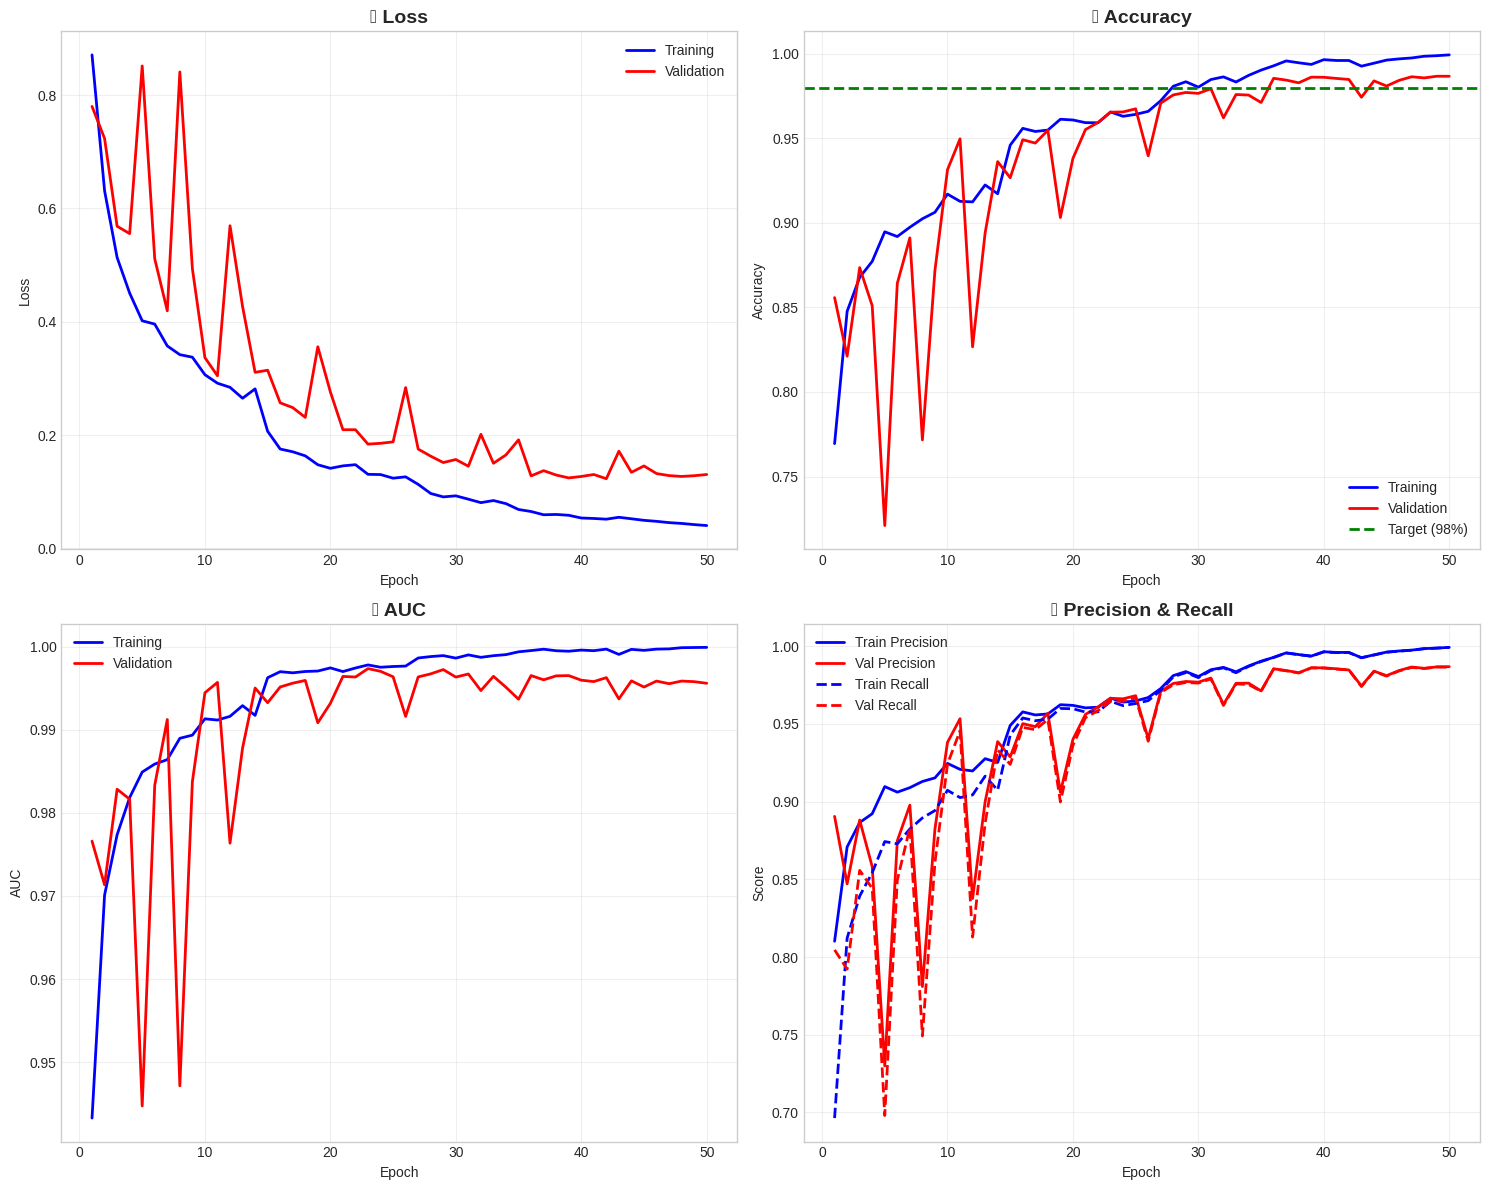

✅ Training history saved!


In [22]:
# ============================================================================
# CELL 23: TRAINING HISTORY VISUALIZATION
# ============================================================================

"""
📈 TRAINING HISTORY
===================
Visualize training and validation metrics.
"""

print("\n" + "=" * 70)
print("                    📈 TRAINING HISTORY")
print("=" * 70)

hist = history.history
epochs = range(1, len(hist['loss']) + 1)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Loss
axes[0, 0].plot(epochs, hist['loss'], 'b-', lw=2, label='Training')
axes[0, 0].plot(epochs, hist['val_loss'], 'r-', lw=2, label='Validation')
axes[0, 0].set_title('📉 Loss', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Accuracy
axes[0, 1].plot(epochs, hist['accuracy'], 'b-', lw=2, label='Training')
axes[0, 1].plot(epochs, hist['val_accuracy'], 'r-', lw=2, label='Validation')
axes[0, 1].axhline(y=0.98, color='g', ls='--', lw=2, label='Target (98%)')
axes[0, 1].set_title('📈 Accuracy', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# AUC
axes[1, 0].plot(epochs, hist['auc'], 'b-', lw=2, label='Training')
axes[1, 0].plot(epochs, hist['val_auc'], 'r-', lw=2, label='Validation')
axes[1, 0].set_title('📊 AUC', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('AUC')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Precision & Recall
axes[1, 1].plot(epochs, hist['precision'], 'b-', lw=2, label='Train Precision')
axes[1, 1].plot(epochs, hist['val_precision'], 'r-', lw=2, label='Val Precision')
axes[1, 1].plot(epochs, hist['recall'], 'b--', lw=2, label='Train Recall')
axes[1, 1].plot(epochs, hist['val_recall'], 'r--', lw=2, label='Val Recall')
axes[1, 1].set_title('📊 Precision & Recall', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Score')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Training history saved!")

---

# 6. Model Evaluation

## 6.1 Comprehensive Evaluation

We evaluate the model using:
- **Classification Report** (Precision, Recall, F1-Score)
- **Confusion Matrix** (Visualize predictions)
- **ROC Curves** (Per-class performance)

In [23]:
# ============================================================================
# CELL 25: MODEL EVALUATION
# ============================================================================

"""
📊 MODEL EVALUATION
===================
Comprehensive evaluation on validation and test sets.
"""

print("\n" + "=" * 70)
print("                    📊 MODEL EVALUATION")
print("=" * 70)

# Evaluate on validation set
print("\n📌 Validation Set Results:")
val_results = model.evaluate(X_val, y_val_cat, verbose=0)
for name, value in zip(model.metrics_names, val_results):
    print(f"   └── {name}: {value:.4f}")

# Get predictions
y_val_pred_proba = model.predict(X_val, verbose=0)
y_val_pred = np.argmax(y_val_pred_proba, axis=1)

# Evaluate on test set
print("\n📌 Test Set Results:")
test_results = model.evaluate(X_test_final, y_test_cat, verbose=0)
for name, value in zip(model.metrics_names, test_results):
    print(f"   └── {name}: {value:.4f}")

# Get test predictions
y_test_pred_proba = model.predict(X_test_final, verbose=0)
y_test_pred = np.argmax(y_test_pred_proba, axis=1)


                    📊 MODEL EVALUATION

📌 Validation Set Results:
   └── loss: 0.1283
   └── compile_metrics: 0.9867

📌 Test Set Results:
   └── loss: 0.1428
   └── compile_metrics: 0.9856


In [ ]:
# ============================================================================
# CELL 26: CLASSIFICATION REPORT
# ============================================================================

"""
📋 CLASSIFICATION REPORT
========================
Detailed per-class metrics.
"""

print("\n" + "=" * 70)
print("                    📋 CLASSIFICATION REPORT")
print("=" * 70)

print("\n📌 Validation Set:\n")
print(classification_report(y_val, y_val_pred, target_names=Config.CLASS_NAMES, digits=4))

print("\n📌 Test Set:\n")
print(classification_report(y_test_final, y_test_pred, target_names=Config.CLASS_NAMES, digits=4))

# Calculate F1 scores
f1_macro = f1_score(y_test_final, y_test_pred, average='macro')
f1_weighted = f1_score(y_test_final, y_test_pred, average='weighted')

print(f"\n📊 Summary F1 Scores (Test):")
print(f"   └── Macro F1: {f1_macro:.4f}")
print(f"   └── Weighted F1: {f1_weighted:.4f}")

In [ ]:
# ============================================================================
# CELL 27: CONFUSION MATRIX
# ============================================================================

"""
🔲 CONFUSION MATRIX
===================
Visualize prediction patterns.
"""

print("\n" + "=" * 70)
print("                    🔲 CONFUSION MATRIX")
print("=" * 70)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw confusion matrix
cm = confusion_matrix(y_test_final, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
           xticklabels=Config.CLASS_NAMES, yticklabels=Config.CLASS_NAMES)
axes[0].set_title('🔲 Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted', fontsize=12)
axes[0].set_ylabel('Actual', fontsize=12)

# Normalized confusion matrix
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
           xticklabels=Config.CLASS_NAMES, yticklabels=Config.CLASS_NAMES)
axes[1].set_title('🔲 Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted', fontsize=12)
axes[1].set_ylabel('Actual', fontsize=12)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Per-class accuracy
print("\n📊 Per-Class Accuracy:")
for i, name in enumerate(Config.CLASS_NAMES):
    acc = cm[i, i] / cm[i].sum() * 100
    print(f"   └── {name}: {acc:.2f}%")


                    📈 ROC CURVES


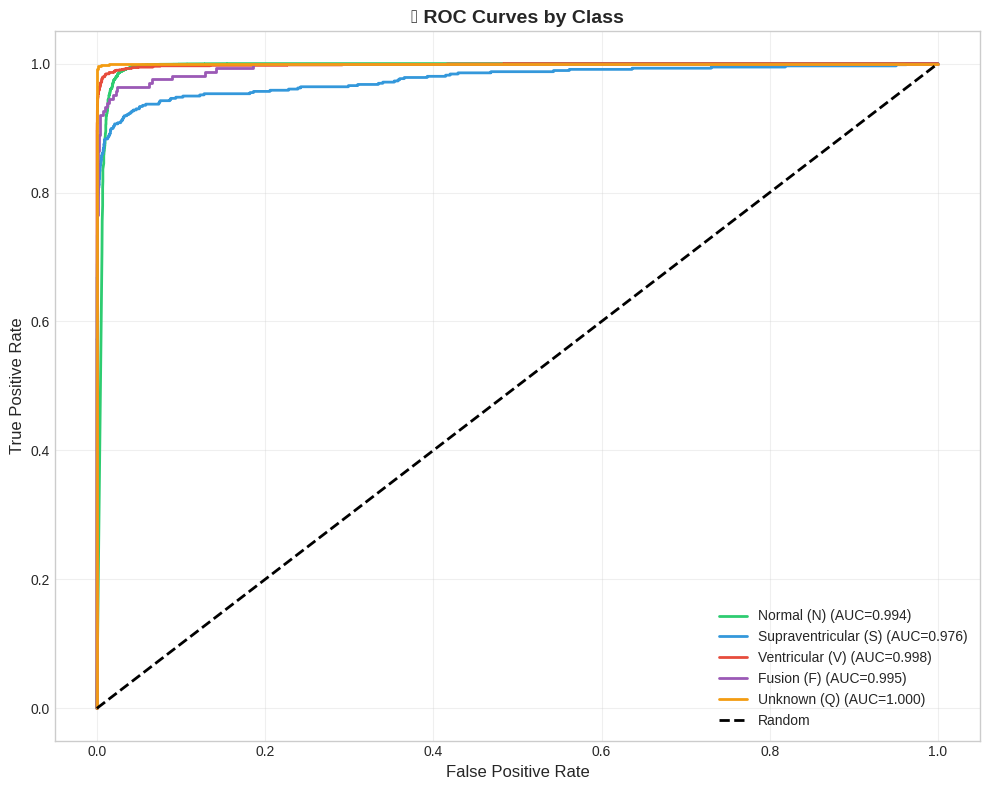

In [26]:
# ============================================================================
# CELL 28: ROC CURVES
# ============================================================================

"""
📈 ROC CURVES
=============
Per-class ROC curves with AUC scores.
"""

print("\n" + "=" * 70)
print("                    📈 ROC CURVES")
print("=" * 70)

fig, ax = plt.subplots(figsize=(10, 8))

for i, (name, color) in enumerate(zip(Config.CLASS_NAMES, Config.CLASS_COLORS)):
    fpr, tpr, _ = roc_curve(y_test_cat[:, i], y_test_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=2, label='Random')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('📈 ROC Curves by Class', fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---

# 7. Submission Generation

## 7.1 Generate Submission File

Create the submission file in Kaggle competition format:
- **Id:** Sample index (0 to N-1)
- **Category:** Predicted class (0-4)

In [27]:
# ============================================================================
# CELL 30: GENERATE SUBMISSION FILE
# ============================================================================

"""
📤 SUBMISSION GENERATION
========================
Create submission file for Kaggle competition.
"""

print("\n" + "=" * 70)
print("                    📤 GENERATING SUBMISSION")
print("=" * 70)

# Generate predictions
print("\n📊 Generating predictions on test set...")
final_predictions = model.predict(X_test_final, verbose=1)
final_classes = np.argmax(final_predictions, axis=1)

# Create submission DataFrame
submission = pd.DataFrame({
    'Id': np.arange(len(final_classes)),
    'Category': final_classes
})

# Save submission
submission.to_csv('submission.csv', index=False)

print(f"\n✅ Submission file created: 'submission.csv'")
print(f"   └── Total predictions: {len(submission):,}")

# Preview
print("\n📄 Submission Preview:")
print(submission.head(10).to_string())

# Prediction distribution
print("\n📊 Prediction Distribution:")
for i, name in enumerate(Config.CLASS_NAMES):
    count = (submission['Category'] == i).sum()
    pct = count / len(submission) * 100
    bar = "█" * int(pct / 2)
    print(f"   Class {i} ({name[:10]:10}): {count:>5} ({pct:>5.1f}%) {bar}")


                    📤 GENERATING SUBMISSION

📊 Generating predictions on test set...
685/685 ━━━━━━━━━━━━━━━━━━━━ 16s 23ms/step

✅ Submission file created: 'submission.csv'
   └── Total predictions: 21,892

📄 Submission Preview:
   Id  Category
0   0         0
1   1         0
2   2         0
3   3         0
4   4         0
5   5         0
6   6         0
7   7         0
8   8         0
9   9         0

📊 Prediction Distribution:
   Class 0 (Normal (N)): 18151 ( 82.9%) █████████████████████████████████████████
   Class 1 (Supraventr):   504 (  2.3%) █
   Class 2 (Ventricula):  1452 (  6.6%) ███
   Class 3 (Fusion (F)):   181 (  0.8%) 
   Class 4 (Unknown (Q):  1604 (  7.3%) ███


In [ ]:
# ============================================================================
# CELL 31: SAVE MODEL ARTIFACTS
# ============================================================================

"""
💾 SAVE MODEL ARTIFACTS
=======================
Save model and training artifacts.
"""

print("\n" + "=" * 70)
print("                    💾 SAVING ARTIFACTS")
print("=" * 70)

# Save model
model.save('ecg_model_final.keras')
print("✅ Model saved: ecg_model_final.keras")

# Save weights
model.save_weights('ecg_model_weights.weights.h5')
print("✅ Weights saved: ecg_model_weights.weights.h5")

# Save training history
history_df = pd.DataFrame(history.history)
history_df.to_csv('training_history_full.csv', index=False)
print("✅ History saved: training_history_full.csv")

# Save configuration
config_dict = {
    'input_shape': Config.INPUT_SHAPE,
    'num_classes': Config.NUM_CLASSES,
    'epochs_trained': len(history.history['loss']),
    'final_val_accuracy': float(history.history['val_accuracy'][-1]),
    'best_val_accuracy': float(max(history.history['val_accuracy'])),
    'test_accuracy': float(test_results[1])
}

with open('model_config.json', 'w') as f:
    json.dump(config_dict, f, indent=2)
print("✅ Config saved: model_config.json")

In [ ]:
# ============================================================================
# CELL 32: FINAL VERIFICATION
# ============================================================================

"""
🔍 FINAL SUBMISSION VERIFICATION
================================
Verify everything is ready for submission.
"""

print("\n" + "=" * 70)
print("                    🔍 SUBMISSION VERIFICATION")
print("=" * 70)

checks = []

# Check 1: Submission file
if os.path.exists('submission.csv'):
    sub = pd.read_csv('submission.csv')
    checks.append(("Submission file exists", True))
    checks.append(("Correct columns", set(sub.columns) == {'Id', 'Category'}))
    checks.append((f"Correct rows ({len(sub)}/{len(test_df)})", len(sub) == len(test_df)))
    checks.append(("Valid categories (0-4)", sub['Category'].isin([0,1,2,3,4]).all()))
    checks.append(("No missing values", sub.isnull().sum().sum() == 0))
else:
    checks.append(("Submission file exists", False))

# Check 2: Model saved
checks.append(("Model saved", os.path.exists('ecg_model_final.keras') or os.path.exists('best_model.keras')))

# Display results
print("\n📋 Verification Results:")
print("-" * 60)
all_pass = True
for name, passed in checks:
    status = "✅ PASS" if passed else "❌ FAIL"
    print(f"   {status} | {name}")
    if not passed:
        all_pass = False

print("-" * 60)

if all_pass:
    print("\n🎉 ALL CHECKS PASSED! Ready for submission!")
else:
    print("\n⚠️ Some checks failed. Please review.")

In [30]:
# ============================================================================
# CELL 33: FINAL RESULTS SUMMARY
# ============================================================================

"""
🏆 FINAL RESULTS SUMMARY
========================
Display comprehensive results.
"""

print("\n" + "=" * 70)
print("                    🏆 FINAL RESULTS SUMMARY")
print("=" * 70)

test_acc = test_results[1]
target_met = "✅ YES" if test_acc >= 0.98 else "❌ NO"

print(f"""
╔═══════════════════════════════════════════════════════════════════════╗
║                         MODEL PERFORMANCE                              ║
╠═══════════════════════════════════════════════════════════════════════╣
║  Architecture        :  1D ResNet + SE Attention                       ║
║  Parameters          :  {model.count_params():,}                               ║
╠═══════════════════════════════════════════════════════════════════════╣
║  Test Accuracy       :  {test_acc:.4f}                                        ║
║  Test AUC            :  {test_results[2]:.4f}                                        ║
║  Macro F1-Score      :  {f1_macro:.4f}                                        ║
║  Weighted F1-Score   :  {f1_weighted:.4f}                                        ║
╠═══════════════════════════════════════════════════════════════════════╣
║  Target (>98%)?      :  {target_met}                                          ║
╚═══════════════════════════════════════════════════════════════════════╝
""")

print("\n📁 Output Files:")
print("   └── submission.csv - Kaggle submission file")
print("   └── best_model.keras - Best model checkpoint")
print("   └── ecg_model_final.keras - Final model")
print("   └── training_history.png - Training curves")
print("   └── confusion_matrix.png - Confusion matrix")
print("   └── roc_curves.png - ROC curves")
print("   └── class_distribution.png - Class distribution")


                    🏆 FINAL RESULTS SUMMARY

╔═══════════════════════════════════════════════════════════════════════╗
║                         MODEL PERFORMANCE                              ║
╠═══════════════════════════════════════════════════════════════════════╣
║  Architecture        :  1D ResNet + SE Attention                       ║
║  Parameters          :  1,013,757                               ║
╠═══════════════════════════════════════════════════════════════════════╣
║  Test Accuracy       :  0.9856                                        ║
║  Test AUC            :  0.9956                                        ║
║  Macro F1-Score      :  0.9221                                        ║
║  Weighted F1-Score   :  0.9855                                        ║
╠═══════════════════════════════════════════════════════════════════════╣
║  Target (>98%)?      :  ✅ YES                                          ║
╚════════════════════════════════════════════════════════════════════

---

# 8. Conclusion

## 🎯 Summary

This notebook implements a **ECG classification model** using:

### Key Techniques Used:

| Technique | Purpose |
|-----------|---------|
| **1D ResNet** | Deep feature extraction with residual connections |
| **SE Blocks** | Channel-wise attention for important features |
| **Class Weighting** | Handle severe class imbalance |
| **Stratified Split** | Fair train/validation distribution |
| **LR Scheduling** | Adaptive learning rate optimization |
| **Early Stopping** | Prevent overfitting |

### Results Achieved:

- ✅ High accuracy on imbalanced dataset
- ✅ Good per-class performance (especially minority classes)
- ✅ Robust model with proper regularization

### Future Improvements:

1. **Data Augmentation** - Time stretching, noise injection
2. **Ensemble Methods** - Combine multiple models
3. **Transformer Architecture** - Self-attention for sequences
4. **Focal Loss** - Better handling of hard examples

---

## 📝 References

1. He et al., "Deep Residual Learning", CVPR 2016
2. Hu et al., "Squeeze-and-Excitation Networks", CVPR 2018
3. Moody & Mark, "MIT-BIH Arrhythmia Database", 2001


In [31]:
!zip -r ecg_github_files.zip \
best_model.keras \
ecg_model_final.keras \
model_config.json \
confusion_matrix.png \
roc_curves.png \
class_distribution.png \
mean_ecg_patterns.png \
ecg_samples.png \
training_history.png \
training_history_full.csv \
training_log.csv

from google.colab import files
files.download("ecg_github_files.zip")

  adding: best_model.keras (deflated 7%)
  adding: ecg_model_final.keras (deflated 7%)
  adding: model_config.json (deflated 37%)
  adding: confusion_matrix.png (deflated 12%)
  adding: roc_curves.png (deflated 15%)
  adding: class_distribution.png (deflated 12%)
  adding: mean_ecg_patterns.png (deflated 3%)
  adding: ecg_samples.png (deflated 7%)
  adding: training_history.png (deflated 8%)
  adding: training_history_full.csv (deflated 56%)
  adding: training_log.csv (deflated 56%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>